In [1]:
import os
import sys
import datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.ticker import MultipleLocator

sys.path.insert(0, '/home/users/zhiyi/PROJECTS_ANALYSIS')

BASE_DIR = Path('/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision')
FIGURE_DATA_DIR = BASE_DIR / 'figure_data'
FIGURE_S7_PATH = FIGURE_DATA_DIR / 'FigureS7.nc'

SCRIP_NE30 = '/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc'
SCRIP_NE60 = '/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc'

FILEBASE_NE30 = '/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist/MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc'
FILEBASE_NE60 = '/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICAv0_ne60_production/atm/hist/MUSICAv0_ne60_production.cam.h2.2018-MM-DD-03600.nc'

START_DATE = datetime.date(2018, 5, 15)
END_DATE = datetime.date(2018, 6, 25)
PLOT_START = '2018-05-15'
PLOT_END = '2018-06-15'


In [2]:
def _daily_files(filebase, start_date=START_DATE, end_date=END_DATE):
    files = []
    current = start_date
    while current <= end_date:
        file_path = filebase.replace('MM', current.strftime('%m')).replace('DD', current.strftime('%d'))
        if os.path.exists(file_path):
            files.append(file_path)
        else:
            print(f'Missing file: {file_path}')
        current += datetime.timedelta(days=1)
    return files


scrip30 = xr.open_dataset(SCRIP_NE30)
scrip60 = xr.open_dataset(SCRIP_NE60)

ds_ne30 = xr.open_mfdataset(_daily_files(FILEBASE_NE30), combine='by_coords')
ds_ne60 = xr.open_mfdataset(_daily_files(FILEBASE_NE60), combine='by_coords')

print('Datasets loaded!')


Datasets loaded!


In [3]:
def get_region_idx(scrip):
    lon360 = scrip['grid_center_lon']
    lat = scrip['grid_center_lat']
    lon = ((lon360 + 180) % 360) - 180
    mask = (lon >= -9) & (lon <= 2) & (lat >= 49.5) & (lat <= 61.5)
    return np.where(mask.values)[0]


def compute_delta_z1(ds):
    g = 9.80665
    r_d = 287.05
    p0_ref = 101325
    a_i = ds['hyai'] * 1000
    b_i = ds['hybi']
    p_interface = a_i + b_i * p0_ref
    p0 = p_interface.isel(ilev=-2)
    p1 = p_interface.isel(ilev=-1)
    t0 = ds['T'].isel(lev=-1)
    valid = (p0 > 0) & (p1 > 0)
    return xr.where(valid, (r_d * t0 / g) * np.log(p1 / p0), np.nan)


idx30 = get_region_idx(scrip30)
idx60 = get_region_idx(scrip60)

vars_with_lev = ['T', 'CLOUD']
vars_no_lev = ['FSDS', 'OMEGA500', 'PRECT', 'PBLH', 'BURDENBCdn']
all_vars = vars_with_lev + vars_no_lev

mean30 = {}
mean60 = {}
for var in all_vars:
    if var in vars_with_lev:
        arr30 = ds_ne30[var].isel(lev=-1, ncol=idx30)
        arr60 = ds_ne60[var].isel(lev=-1, ncol=idx60)
    else:
        arr30 = ds_ne30[var].isel(ncol=idx30)
        arr60 = ds_ne60[var].isel(ncol=idx60)
    mean30[var] = arr30.mean(dim='ncol')
    mean60[var] = arr60.mean(dim='ncol')

dz1_30 = compute_delta_z1(ds_ne30).isel(ncol=idx30).mean(dim='ncol')
dz1_60 = compute_delta_z1(ds_ne60).isel(ncol=idx60).mean(dim='ncol')


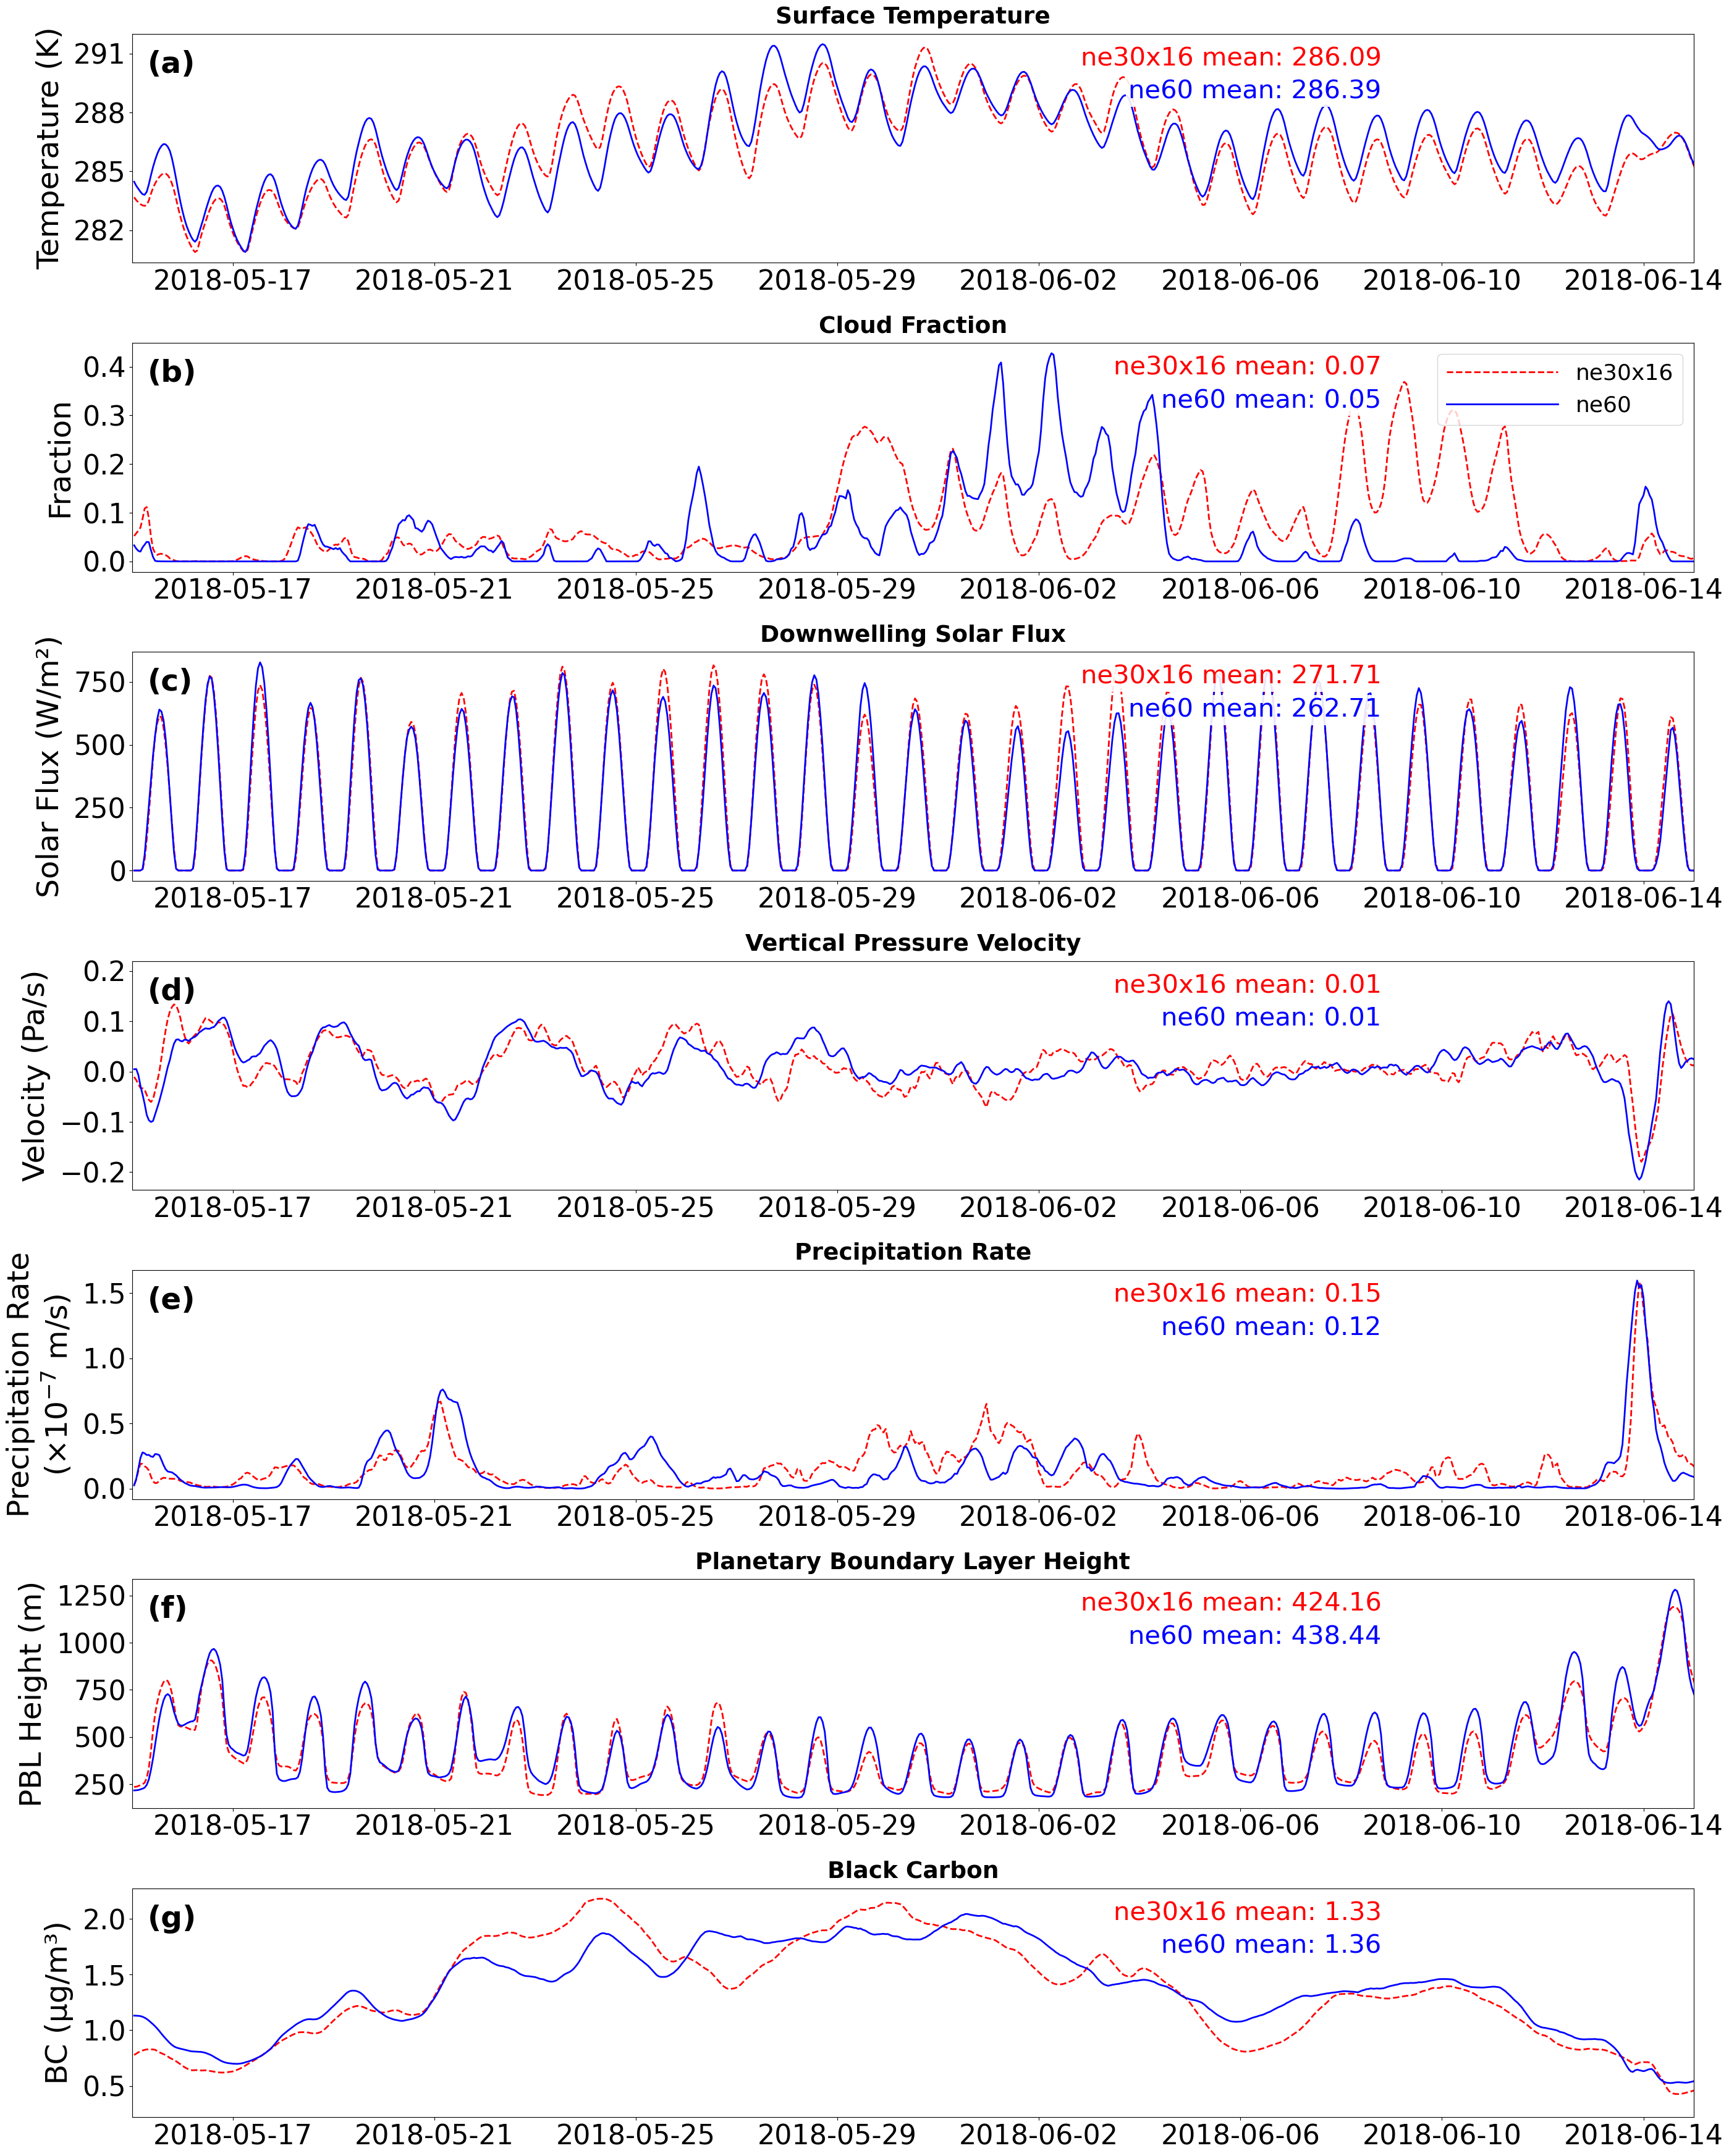

In [4]:
titles = [
    'Surface Temperature',
    'Cloud Fraction',
    'Downwelling Solar Flux',
    'Vertical Pressure Velocity',
    'Precipitation Rate',
    'Planetary Boundary Layer Height',
    'Black Carbon',
]

ylabels = [
    'Temperature (K)',
    'Fraction',
    'Solar Flux (W/m²)',
    'Velocity (Pa/s)',
    'Precipitation Rate\n($\\times10^{-7}$ m/s)',
    'PBL Height (m)',
    'BC (µg/m³)',
]

letters = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)']

ylims = {
    'T': None,
    'CLOUD': None,
    'FSDS': None,
    'OMEGA500': None,
    'PRECT': None,
    'PBLH': None,
    'BURDENBCdn': None,
}

ytick_intervals = {
    'T': 3,
    'CLOUD': 0.1,
    'FSDS': None,
    'OMEGA500': 0.1,
    'PRECT': None,
    'PBLH': 250,
    'BURDENBCdn': 0.5,
}

plot_units = {
    'T': 'K',
    'CLOUD': 'fraction',
    'FSDS': 'W m-2',
    'OMEGA500': 'Pa s-1',
    'PRECT': '1e-7 m s-1',
    'PBLH': 'm',
    'BURDENBCdn': 'ug m-3',
}


def make_figure_s7_dataset():
    plot_vars = {}
    for var, title in zip(all_vars, titles):
        data30 = mean30[var]
        data60 = mean60[var]

        if var == 'BURDENBCdn':
            data30 = (data30 / dz1_30) * 1e9
            data60 = (data60 / dz1_60) * 1e9
        if var == 'PRECT':
            data30 = data30 * 1e7
            data60 = data60 * 1e7

        plot_data = xr.concat(
            [data30, data60],
            dim=pd.Index(['ne30x16', 'ne60'], name='simulation'),
        )
        plot_data.name = var
        plot_data.attrs['plot_title'] = title
        plot_data.attrs['plot_units'] = plot_units[var]
        plot_vars[var] = plot_data

    figure_ds = xr.Dataset(plot_vars)
    figure_ds.attrs.update({
        'description': 'Final plotted UK-region mean meteorological time series. PRECT and BURDENBCdn include plotting unit conversions.',
        'region': 'lon -9 to 2, lat 49.5 to 61.5',
        'saved_time_range': 'full loaded time range, matching the ax.plot inputs',
        'plot_xlim': f'{PLOT_START} to {PLOT_END}',
        'source_notebook': str(BASE_DIR / 'original' / 'FigureS7' / '0.1_Met_Timeseries_faser.ipynb'),
    })
    return figure_ds


def plot_met_timeseries(figure_ds):
    fig, axes = plt.subplots(nrows=len(all_vars), ncols=1, figsize=(28, 5 * len(all_vars)))
    for idx, (ax, var, title, ylabel) in enumerate(zip(axes, all_vars, titles, ylabels)):
        data30 = figure_ds[var].sel(simulation='ne30x16')
        data60 = figure_ds[var].sel(simulation='ne60')

        ax.text(
            0.01, 0.93, letters[idx],
            transform=ax.transAxes,
            fontsize=35,
            fontweight='bold',
            va='top',
            ha='left',
        )

        sel_slice = slice(PLOT_START, PLOT_END)
        mean_val30 = float(data30.sel(time=sel_slice).mean(dim='time').values)
        mean_val60 = float(data60.sel(time=sel_slice).mean(dim='time').values)

        ax.text(
            0.8, 0.945,
            f'ne30x16 mean: {mean_val30:.2f}',
            transform=ax.transAxes,
            fontsize=30,
            color='red',
            va='top',
            ha='right',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=3),
        )
        ax.text(
            0.8, 0.8,
            f'ne60 mean: {mean_val60:.2f}',
            transform=ax.transAxes,
            fontsize=30,
            color='blue',
            va='top',
            ha='right',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=3),
        )

        ax.plot(data30.time, data30, 'r--', label='ne30x16', linewidth=2.0)
        ax.plot(data60.time, data60, 'b-', label='ne60', linewidth=2.0)
        ax.set_title(title, fontsize=27, pad=12, weight='bold')
        ax.set_ylabel(ylabel, fontsize=35, labelpad=10)

        if ylims[var] is not None:
            ax.set_ylim(ylims[var])
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.set_xlim(pd.to_datetime(PLOT_START), pd.to_datetime(PLOT_END))

        if ytick_intervals[var] is not None:
            ax.yaxis.set_major_locator(MultipleLocator(ytick_intervals[var]))
        ax.tick_params(axis='both', which='major', labelsize=32)
        if idx == 1:
            ax.legend(fontsize=26, loc='upper right', handlelength=5)

    plt.tight_layout()
    fig.subplots_adjust(hspace=0.35)
    return fig, axes


FigureS7_raw = make_figure_s7_dataset()
fig, axes = plot_met_timeseries(FigureS7_raw)


In [5]:
FIGURE_DATA_DIR.mkdir(parents=True, exist_ok=True)
FigureS7_raw.to_netcdf(FIGURE_S7_PATH)
FigureS7_raw.close()
print(FIGURE_S7_PATH)


/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS7.nc


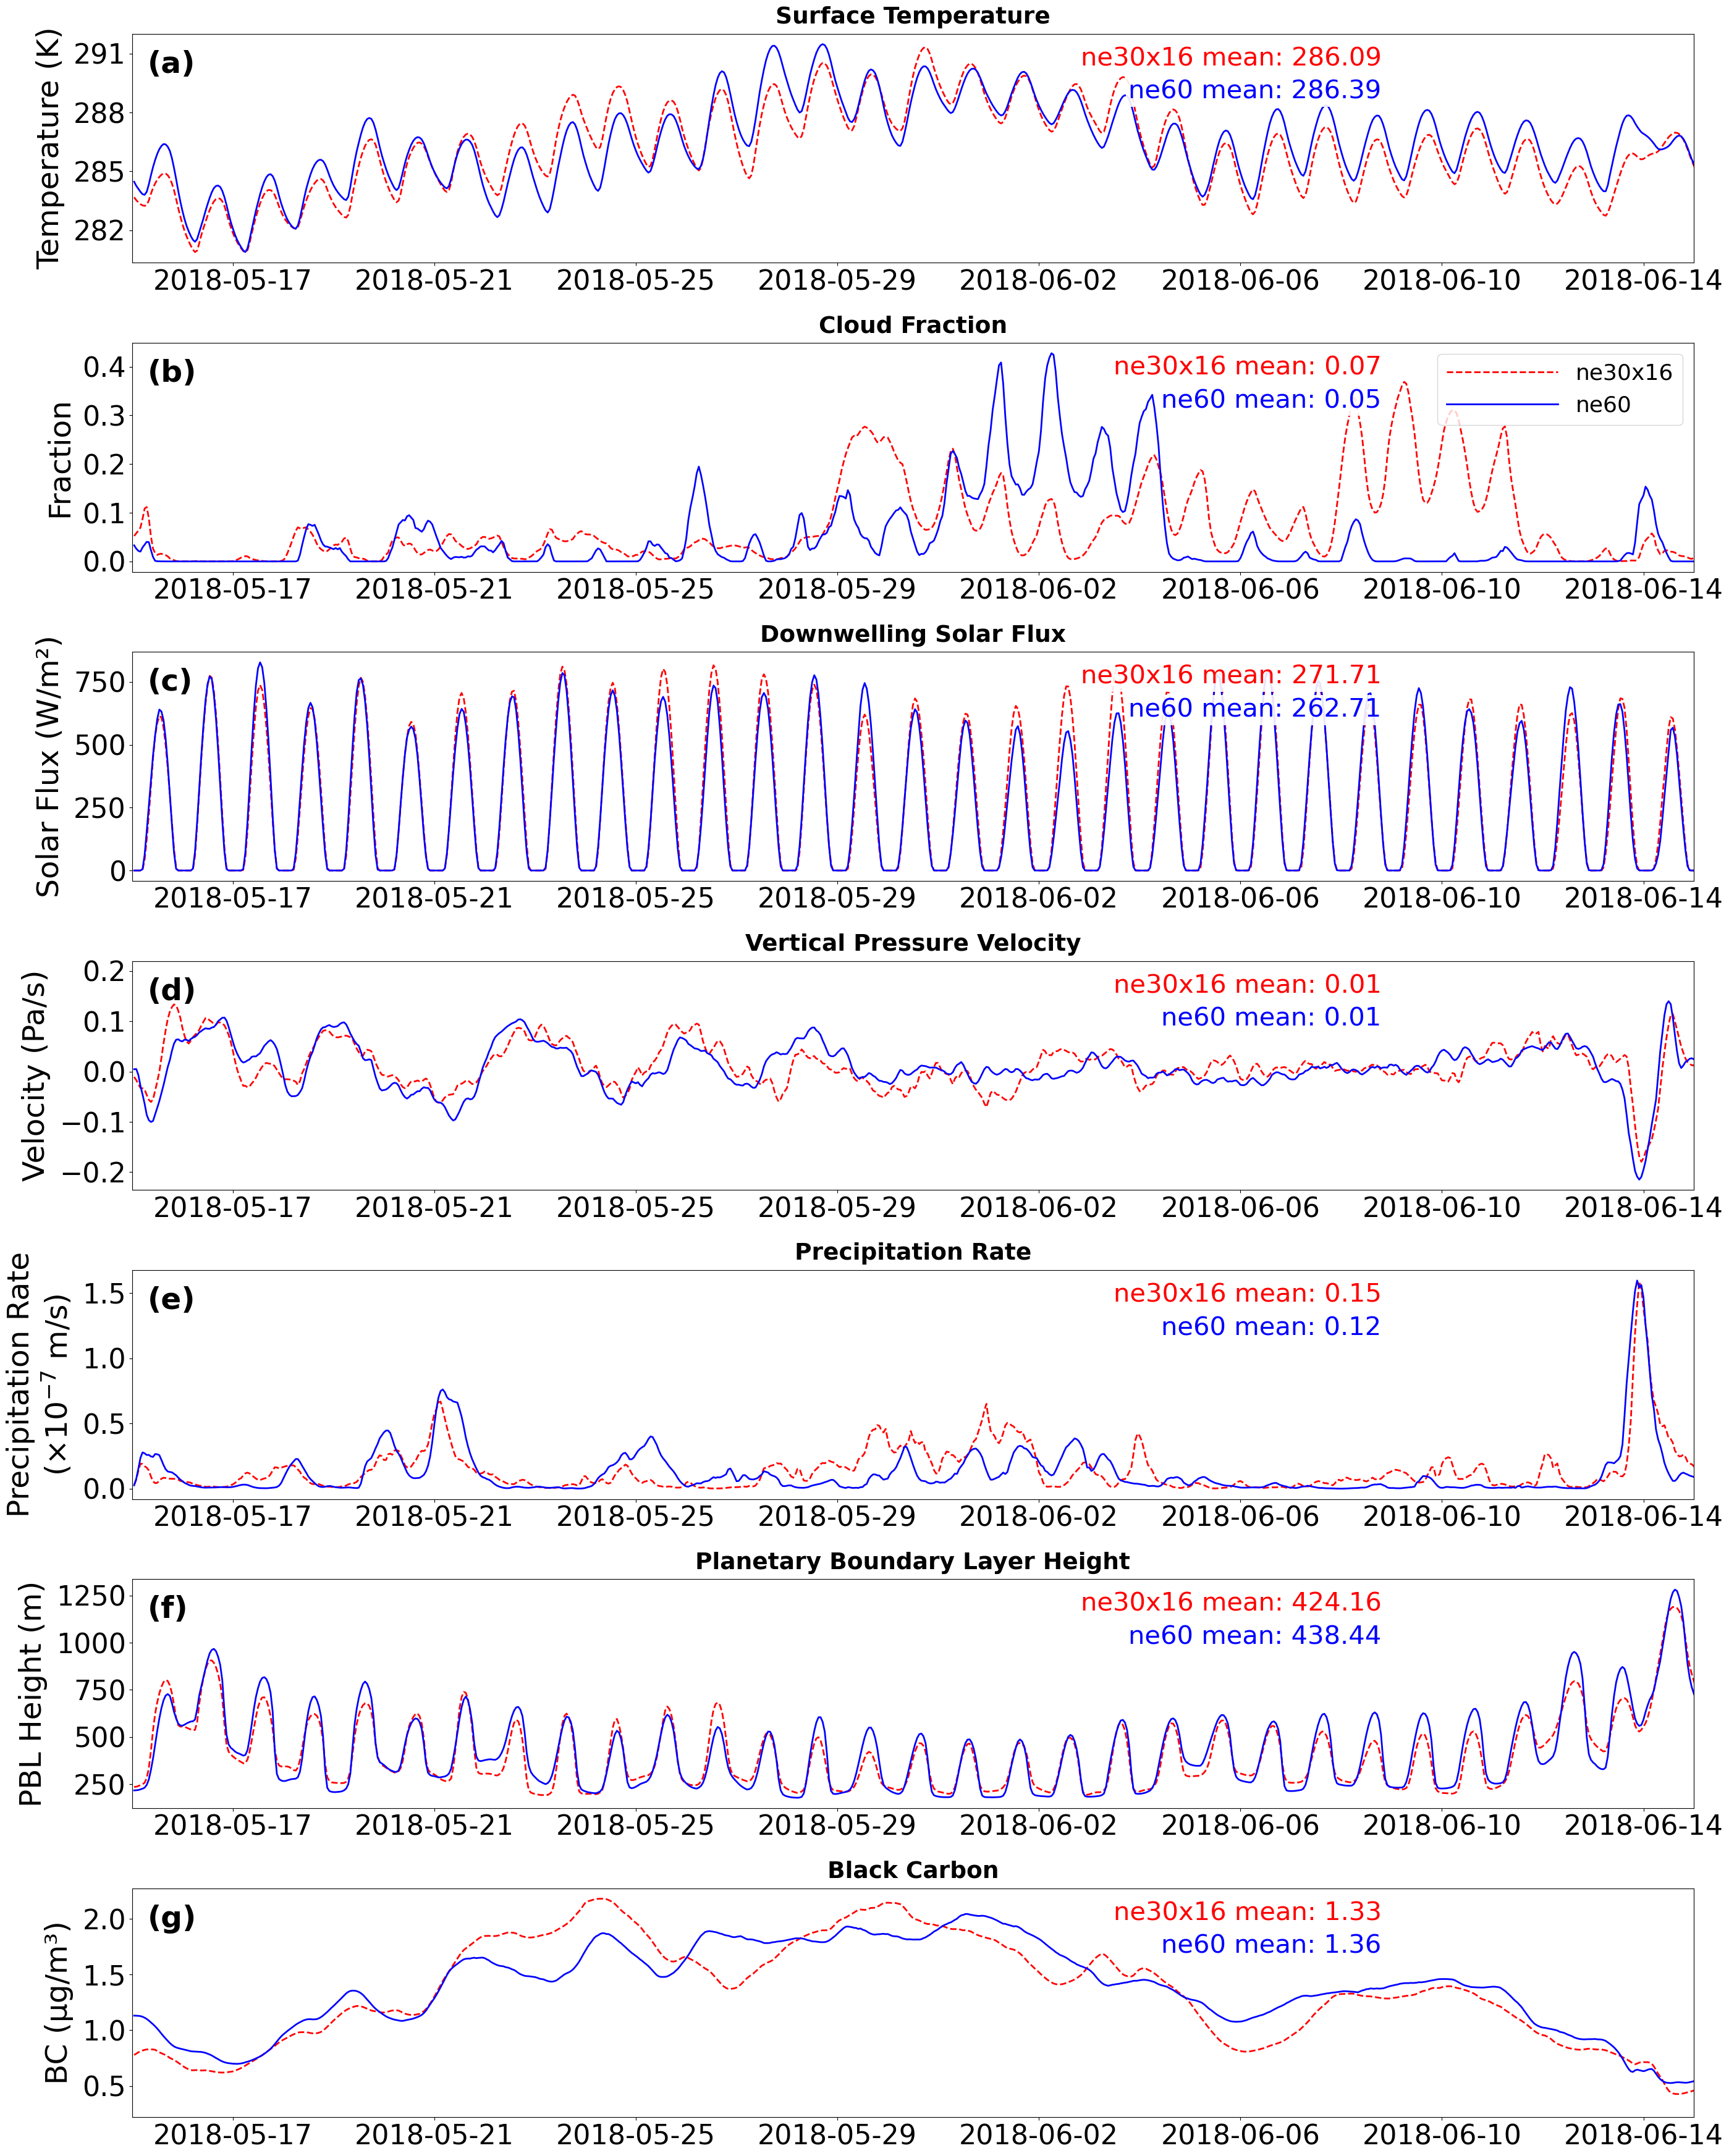

In [7]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.ticker import MultipleLocator

BASE_DIR = Path('/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision')
FIGURE_S7_PATH = BASE_DIR / 'figure_data' / 'FigureS7.nc'
PLOT_START = '2018-05-15'
PLOT_END = '2018-06-15'

FigureS7_saved = xr.open_dataset(FIGURE_S7_PATH)
all_vars = ['T', 'CLOUD', 'FSDS', 'OMEGA500', 'PRECT', 'PBLH', 'BURDENBCdn']

titles = [
    'Surface Temperature',
    'Cloud Fraction',
    'Downwelling Solar Flux',
    'Vertical Pressure Velocity',
    'Precipitation Rate',
    'Planetary Boundary Layer Height',
    'Black Carbon',
]

ylabels = [
    'Temperature (K)',
    'Fraction',
    'Solar Flux (W/m²)',
    'Velocity (Pa/s)',
    'Precipitation Rate\n($\\times10^{-7}$ m/s)',
    'PBL Height (m)',
    'BC (µg/m³)',
]

letters = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)']

ylims = {
    'T': None,
    'CLOUD': None,
    'FSDS': None,
    'OMEGA500': None,
    'PRECT': None,
    'PBLH': None,
    'BURDENBCdn': None,
}

ytick_intervals = {
    'T': 3,
    'CLOUD': 0.1,
    'FSDS': None,
    'OMEGA500': 0.1,
    'PRECT': None,
    'PBLH': 250,
    'BURDENBCdn': 0.5,
}


def plot_met_timeseries(figure_ds):
    fig, axes = plt.subplots(nrows=len(all_vars), ncols=1, figsize=(28, 5 * len(all_vars)))
    for idx, (ax, var, title, ylabel) in enumerate(zip(axes, all_vars, titles, ylabels)):
        data30 = figure_ds[var].sel(simulation='ne30x16')
        data60 = figure_ds[var].sel(simulation='ne60')

        ax.text(
            0.01, 0.93, letters[idx],
            transform=ax.transAxes,
            fontsize=35,
            fontweight='bold',
            va='top',
            ha='left',
        )

        sel_slice = slice(PLOT_START, PLOT_END)
        mean_val30 = float(data30.sel(time=sel_slice).mean(dim='time').values)
        mean_val60 = float(data60.sel(time=sel_slice).mean(dim='time').values)

        ax.text(
            0.8, 0.945,
            f'ne30x16 mean: {mean_val30:.2f}',
            transform=ax.transAxes,
            fontsize=30,
            color='red',
            va='top',
            ha='right',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=3),
        )
        ax.text(
            0.8, 0.8,
            f'ne60 mean: {mean_val60:.2f}',
            transform=ax.transAxes,
            fontsize=30,
            color='blue',
            va='top',
            ha='right',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=3),
        )

        ax.plot(data30.time, data30, 'r--', label='ne30x16', linewidth=2.0)
        ax.plot(data60.time, data60, 'b-', label='ne60', linewidth=2.0)
        ax.set_title(title, fontsize=27, pad=12, weight='bold')
        ax.set_ylabel(ylabel, fontsize=35, labelpad=10)

        if ylims[var] is not None:
            ax.set_ylim(ylims[var])
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.set_xlim(pd.to_datetime(PLOT_START), pd.to_datetime(PLOT_END))

        if ytick_intervals[var] is not None:
            ax.yaxis.set_major_locator(MultipleLocator(ytick_intervals[var]))
        ax.tick_params(axis='both', which='major', labelsize=32)
        if idx == 1:
            ax.legend(fontsize=26, loc='upper right', handlelength=5)

    plt.tight_layout()
    fig.subplots_adjust(hspace=0.35)
    return fig, axes


fig, axes = plot_met_timeseries(FigureS7_saved)

FIGURES_DIR = BASE_DIR / 'figures' / 'SI'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RASTER_DPI = 300
png_path = FIGURES_DIR / 'FigureS7.png'
pdf_path = FIGURES_DIR / 'FigureS7.pdf'

fig.savefig(png_path, dpi=RASTER_DPI, bbox_inches='tight', facecolor='white')

img = plt.imread(png_path)
height_px, width_px = img.shape[:2]
pdf_fig = plt.figure(figsize=(width_px / RASTER_DPI, height_px / RASTER_DPI), dpi=RASTER_DPI)
pdf_ax = pdf_fig.add_axes([0, 0, 1, 1])
pdf_ax.imshow(img)
pdf_ax.axis('off')
pdf_fig.savefig(pdf_path, format='pdf', dpi=RASTER_DPI, bbox_inches=None, pad_inches=0, facecolor='white')
plt.close(pdf_fig)
